<div style="padding:22px 26px;border-radius:8px;background:rgba(74,58,167,0.08);border-left:6px solid #4A3AA7"><div style="font-size:0.8em;letter-spacing:0.12em;text-transform:uppercase;color:#8A94A3">CHURN-VALUE · pipeline stage 01</div><div style="font-size:2em;font-weight:700;margin:4px 0 6px;color:#4A3AA7">Data ingestion</div><div style="font-size:1.05em;opacity:0.85">Where the data comes from, and whether our copy can be trusted.</div></div>

Every later number in this project is only as good as the file it starts from. This stage
asks two questions before anything is analysed: *is this the dataset we think it is?* and
*what does it look like before we touch it?*

**Pipeline rule.** This notebook downloads nothing and changes nothing. The CLI stage
`churnvalue download` fetches the archive, verifies its pinned SHA-256 and converts the
workbook to Parquet; here we re-verify that artifact and describe it. Quirks found in the raw
data are *surfaced* here and *resolved* in stage 02.

| | |
|---|---|
| **Input** | `data/raw/online_retail_ii.zip` · `data/interim/raw.parquet` (from `churnvalue download`) |
| **Outputs** | `reports/results/01_summary.json` · `reports/figures/01_*.png` |
| **Parameters** | `configs/default.yaml` → `data` |
| **Shared code** | `churnvalue.data.download` (checksum, sheet metadata) · `churnvalue.viz.style` |

<div style="display:flex;gap:8px;flex-wrap:wrap;margin:8px 0 4px;font-family:monospace;font-size:0.85em"><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">I1 provenance</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">I2 integrity</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">I3 raw schema</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">I4 raw quirks</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">✓ hand-off</span></div>

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from churnvalue.config import load_config, project_root
from churnvalue.data.clean import PRODUCT_CODE_PATTERN
from churnvalue.data.download import label_sheets, raw_sheet_rows, sha256_of
from churnvalue.reporting import StageSummary
from churnvalue.viz import style
from churnvalue.viz.style import INK, MUTED, NEUTRAL, RETAINED

os.chdir(project_root())
CFG = load_config()
STAGE, FIGURES, RESULTS = "01", Path("reports/figures"), Path("reports/results")
S = StageSummary(STAGE)  # every number quoted in the text is collected here
style.apply_style()


def save(fig, name):
    return style.save_fig(fig, FIGURES, STAGE, name)


ZIP = CFG.data.raw_dir / "online_retail_ii.zip"
RAW = CFG.data.interim_dir / "raw.parquet"

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">I1 · Provenance and licence</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">who produced the data, and what we may do with it</span></div>

| | |
|---|---|
| **Dataset** | Online Retail II — Chen, D. (2012), UCI Machine Learning Repository |
| **DOI** | [10.24432/C5CG6D](https://doi.org/10.24432/C5CG6D) |
| **Licence** | CC BY 4.0 — redistribution and derived artifacts allowed with attribution |
| **Business** | UK-based, store-less online retailer of all-occasion giftware; many customers are wholesalers |
| **Grain** | one row per **invoice line** (invoice × product), December 2009 – December 2011 |
| **Currency** | pound sterling (£) |

Two properties of the business shape everything that follows. It is **non-contractual**: a
customer never announces that they are leaving, they simply stop buying — so churn has to be
*defined* (stage 04). And many customers are **resellers** buying in bulk, so order values are
heavy-tailed and purchase rhythms are regular, which is what makes cadence informative.

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">I2 · Integrity</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">the pinned checksum, verified again</span></div>

The expected SHA-256 lives in `configs/default.yaml`; `churnvalue download` refuses a file
that does not match it. Verifying it again here makes the notebook self-certifying: if the
check below passes, every figure in stages 01–06 was computed from the published archive.

In [2]:
actual = sha256_of(ZIP)
S["sha256_expected"] = CFG.data.sha256
S["sha256_actual"] = actual
S["sha256_match"] = actual == CFG.data.sha256
S["zip_mb"] = round(ZIP.stat().st_size / 1e6, 1)
S["parquet_mb"] = round(RAW.stat().st_size / 1e6, 1)
assert S["sha256_match"], "the archive does not match the pinned checksum"

display(
    pd.DataFrame(
        {
            "file": [ZIP.name, RAW.name],
            "size (MB)": [S["zip_mb"], S["parquet_mb"]],
            "role": ["published archive (verified)", "both sheets as one table"],
        }
    ).style.hide(axis="index")
)
print(f"SHA-256 {actual}  ->  {'MATCH' if S['sha256_match'] else 'MISMATCH'}")

file,size (MB),role
online_retail_ii.zip,45.600000,published archive (verified)
raw.parquet,7.200000,both sheets as one table


SHA-256 572e36277c2390fbfde10664750731e0a86f55e33470d91919085f0408e67bfb  ->  MATCH


<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">I3 · Raw schema</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">two sheets, eight columns, one overlap</span></div>

The workbook ships as two sheets, one per year. `churnvalue download` stacks them and records
each sheet's row count in the Parquet metadata, so the provenance of every row survives the
conversion.

In [3]:
raw = pd.read_parquet(RAW)
sheets = raw_sheet_rows(RAW)
raw["sheet"] = label_sheets(len(raw), sheets)

per_sheet = raw.groupby("sheet", sort=False)["InvoiceDate"].agg(["size", "min", "max"])
per_sheet.columns = ["rows", "first invoice", "last invoice"]
display(per_sheet)

overlap_start = per_sheet["first invoice"].iloc[1].normalize()
overlap_end = per_sheet["last invoice"].iloc[0]
in_overlap = raw["InvoiceDate"].between(overlap_start, overlap_end)
S["rows_total"] = len(raw)
S["rows_per_sheet"] = sheets
S["date_min"] = raw["InvoiceDate"].min()
S["date_max"] = raw["InvoiceDate"].max()
S["overlap_days"] = (overlap_end.normalize() - overlap_start).days + 1
S["overlap_rows_exported_twice"] = int((in_overlap & (raw["sheet"] == list(sheets)[1])).sum())

schema = pd.DataFrame(
    {
        "dtype": raw.drop(columns="sheet").dtypes.astype(str),
        "non-null %": raw.drop(columns="sheet").notna().mean().mul(100).round(1),
        "distinct": raw.drop(columns="sheet").nunique(),
        "example": raw.drop(columns="sheet").iloc[0],
    }
)
display(schema)

,rows,first invoice,last invoice
sheet,,,
Year 2009-2010,525461,2009-12-01 07:45:00,2010-12-09 20:01:00
Year 2010-2011,541910,2010-12-01 08:26:00,2011-12-09 12:50:00


,dtype,non-null %,distinct,example
Invoice,str,100.0,53628,489434
StockCode,str,100.0,5305,85048
Description,str,99.6,5698,15CM CHRISTMAS GLASS BALL 20 LIGHTS
Quantity,int64,100.0,1057,12
InvoiceDate,datetime64[us],100.0,47635,2009-12-01 07:45:00
Price,float64,100.0,2807,6.95
Customer ID,float64,77.2,5942,13085.0
Country,str,100.0,43,United Kingdom


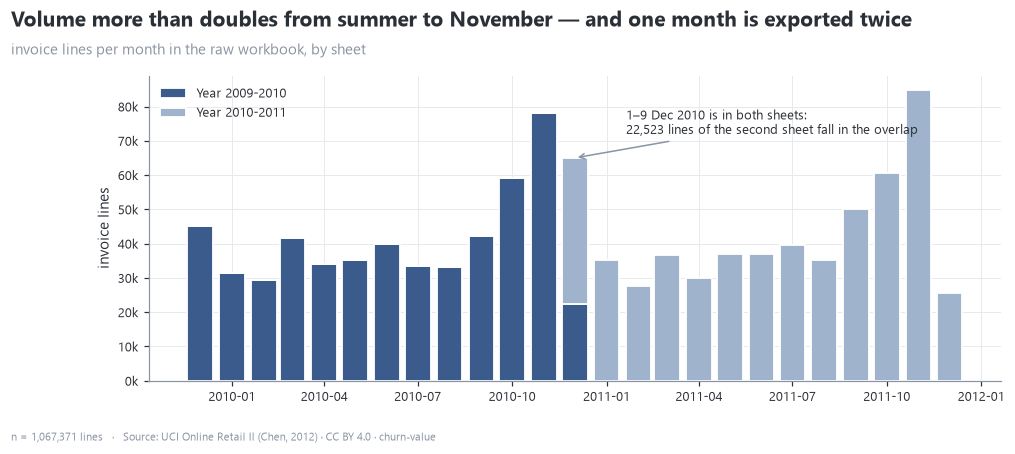

In [4]:
monthly = (
    raw.assign(month=raw["InvoiceDate"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "sheet"], sort=False)
    .size()
    .unstack("sheet")
    .fillna(0)
)
fig, ax = plt.subplots(figsize=(10, 3.6))
first, second = list(sheets)
bar = {"width": 25, "edgecolor": "white", "linewidth": 1.2}
ax.bar(monthly.index, monthly[first], color=NEUTRAL, label=first, **bar)
ax.bar(monthly.index, monthly[second], bottom=monthly[first], color="#9FB3CC", label=second, **bar)
dec = pd.Timestamp("2010-12-01")
ax.annotate(
    f"1–{S['overlap_days']} Dec 2010 is in both sheets:\n"
    f"{S['overlap_rows_exported_twice']:,} lines of the second sheet fall in the overlap",
    xy=(dec, monthly.loc[dec].sum()),
    xytext=(pd.Timestamp("2011-01-20"), 72_000),
    fontsize=8.5,
    color=INK,
    arrowprops={"arrowstyle": "->", "color": MUTED, "lw": 1},
)
ax.set_ylabel("invoice lines")
ax.yaxis.set_major_formatter(lambda v, _: f"{v / 1e3:.0f}k")
ax.legend(loc="upper left")
lines_by_month = monthly.sum(axis=1)
S["nov_over_aug"] = {
    str(y): lines_by_month[pd.Timestamp(f"{y}-11-01")] / lines_by_month[pd.Timestamp(f"{y}-08-01")]
    for y in (2010, 2011)
}
style.headline(
    fig,
    "Volume more than doubles from summer to November — and one month is exported twice",
    "invoice lines per month in the raw workbook, by sheet",
)
style.add_source(fig, f"n = {S['rows_total']:,} lines")
save(fig, "lines_per_month")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">I4 · Raw quirks</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">surfaced here, resolved in stage 02</span></div>

The raw file mixes sales with things that are not sales. Each line below is counted, not
fixed: stage 02 decides what to do with each, rule by rule, with its cost in rows and revenue.

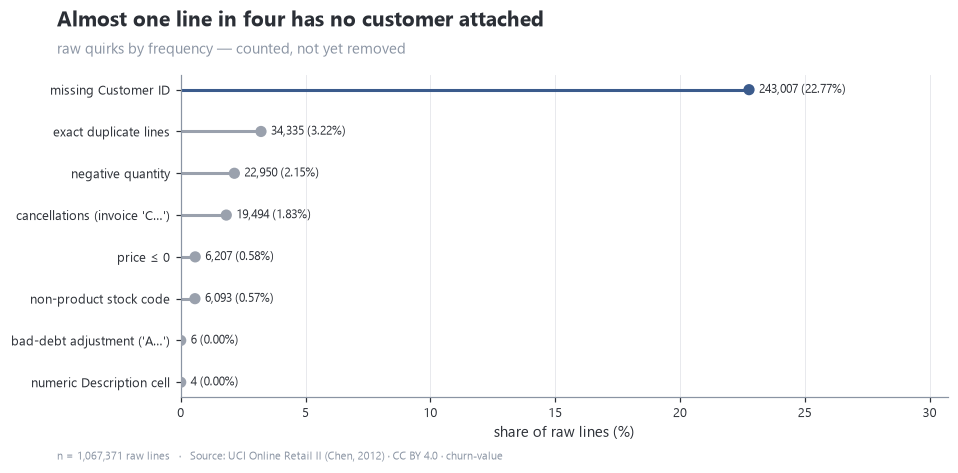

In [5]:
invoice = raw["Invoice"]
quirks = pd.Series(
    {
        "missing Customer ID": raw["Customer ID"].isna().sum(),
        "exact duplicate lines": raw.drop(columns="sheet").duplicated().sum(),
        "cancellations (invoice 'C…')": invoice.str.startswith("C").sum(),
        "negative quantity": (raw["Quantity"] < 0).sum(),
        "non-product stock code": (~raw["StockCode"].str.match(PRODUCT_CODE_PATTERN)).sum(),
        "price ≤ 0": (raw["Price"] <= 0).sum(),
        "bad-debt adjustment ('A…')": invoice.str.startswith("A").sum(),
        "numeric Description cell": raw["Description"].fillna("").str.fullmatch(r"\d+").sum(),
    }
).sort_values()
S["quirks"] = quirks.to_dict()
S["missing_customer_share"] = raw["Customer ID"].isna().mean()

fig, ax = plt.subplots(figsize=(9, 3.8))
share = quirks / len(raw) * 100
colors = [NEUTRAL if k == "missing Customer ID" else RETAINED for k in quirks.index]
ax.hlines(quirks.index, 0, share, color=colors, lw=2)
ax.scatter(share, quirks.index, color=colors, s=40, zorder=3)
for label, value in share.items():
    ax.text(
        value + 0.4, label, f"{quirks[label]:,} ({value:.2f}%)", va="center", fontsize=8, color=INK
    )
ax.set_xlabel("share of raw lines (%)")
ax.set_xlim(0, share.max() * 1.35)
ax.grid(axis="y", visible=False)
style.headline(
    fig,
    "Almost one line in four has no customer attached",
    "raw quirks by frequency — counted, not yet removed",
)
style.add_source(fig, f"n = {len(raw):,} raw lines")
save(fig, "quirks")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">✓ · Summary and hand-off</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">01 → 02</span></div>

**Produced** — `reports/results/01_summary.json` (every number above) and the figures
`01_lines_per_month`, `01_quirks`.

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #B7791F;background:rgba(183,121,31,0.12);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#B7791F">Key finding</span><ul style="margin:6px 0 0 18px;padding:0"><li>The published archive matches the pinned SHA-256, so the analysis is reproducible from a public, licensed source.</li><li>The two sheets overlap on 1–9 December 2010: part of the "duplicates" is an export artefact, not customer behaviour.</li><li>22.8 % of lines have no customer: they cannot be followed over time, so they can never enter a churn label.</li></ul></div>

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#4A3AA7">Decision taken here</span><ul style="margin:6px 0 0 18px;padding:0"><li>None on the data. This stage verifies and describes; the table is unchanged.</li></ul></div>

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #3B5B8C;background:rgba(59,91,140,0.10);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#3B5B8C">Left for a later stage</span><ul style="margin:6px 0 0 18px;padding:0"><li><b>02_data_cleaning</b> — one explicit rule per quirk, applied in a fixed order, with rows and revenue removed by each.</li><li><b>03_eda</b> — the autumn volume peak seen here becomes the seasonality question.</li></ul></div>

In [6]:
S.write(RESULTS)

WindowsPath('reports/results/01_summary.json')